## Notebook informe final (estructura modularizada) - Procesamiento de Datos TP1
#### Alumna: Sol Josefina Mercado Jacobsen
#### DNI 38.442.698

### 1 . Setup
importacion de las librerias y modulos necesarios

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent
if str(RAIZ) not in sys.path:
    sys.path.append(str(RAIZ))

import pandas as pd
from IPython.display import Image, display

from utils.configuracion import cargar_config
from extract.extract import leer_dataset, exploracion_inicial
from transform.transform import construir_silver, construir_gold

## 2. Consigna 1
* Carga de la configuracion (config.yaml)
* Lectura del dataset crudo mediante la funcion 'leer_dataset'
* Generacion de reporte  

In [2]:
config = cargar_config(str(RAIZ / "config" / "config.yaml"))
df = leer_dataset(str(RAIZ / config["rutas"]["bronze"]))
informe = exploracion_inicial(df)

Scroll ↓ (shape, info, nulls, describe numerico y categorico)
----------------------------------------------------------------------------------------------------
Shape: filas y columnas: (14644, 47)
----------------------------------------------------------------------------------------------------

Info dataset crudo
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 14644 entries, 0 to 14643
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Dis No                           14644 non-null  str    
 1   Year                             14644 non-null  int64  
 2   Seq                              14644 non-null  int64  
 3   Glide                            1581 non-null   str    
 4   Disaster Group                   14644 non-null  str    
 5   Disaster Subgroup                14644 no

## 3 Consigna 2 y 3.
Transformacion y generacion de graficos
### Ruta silver (mediante las funciones creadas): 
* Lee el dataset desde la ruta bronce (csv crudo)
* Selecciona las columnas que utilizará el informe
* Normaliza las columnas
* Imputa nulos con dos metodos distintos, imputacion con promedio ponderado para mes de inicio y fillna para dia de inicio
* Unifica la fecha como pide la consigna
* Recorta el periodo temporal pedido por consigna (ultimos 20 años)
* Guarda el data frame procesado en ruta silver
* Retorna la ruta de salida que contiene "desastres_limpios.parquet" (conserva dtypes)

### Ruta gold (mediante las funciones creadas):
* Lee el archivo parquet almacenado en la ruta silver
* Genera las tablas de cruces de informacion necesarias para los graficos utilizando las funciones correspondientes a cada tabla (procesa el df y retorna una pivot table)
* Guarda cada tabla en la ruta gold
* Retorna la ruta 

In [3]:
ruta_silver = construir_silver(str(RAIZ / config["rutas"]["bronze"]), config)
rutas_gold = construir_gold(ruta_silver, config)

### Patrones estacionales en la ocurrencia de desastres naturales (2002-2021)

La distribución mensual global muestra dos picos: enero (938 eventos) y 
julio-agosto (879 y 868 eventos). El pico de julio-agosto es explicable por 
la estacionalidad climática del hemisferio norte (mayor frecuencia de 
temperaturas extremas e incendios forestales, sumado a un pico de 
inundaciones).

El pico de enero combina dos factores. Por un lado, Flood y Storm siguen 
siendo los tipos predominantes, igual que en el resto del año. Por otro, se 
observa una sobrerrepresentación de eventos de tipo Epidemic (185 casos, 
tercer lugar, contra solo 51 en julio), que no responde a estacionalidad 
climática sino, probablemente, a la forma en que se reportan y consolidan 
administrativamente los brotes epidémicos, muchas veces sistematizados al 
cierre o inicio del año calendario.

Descartada ademas una contaminacion de los datos por parte de la imputacion ya que para la columna de mes la decision fue imputar con un muestrreo aleatorio poderado y no con fillna(1) que provocaría un aumento de registros artificial par el mes de Enero

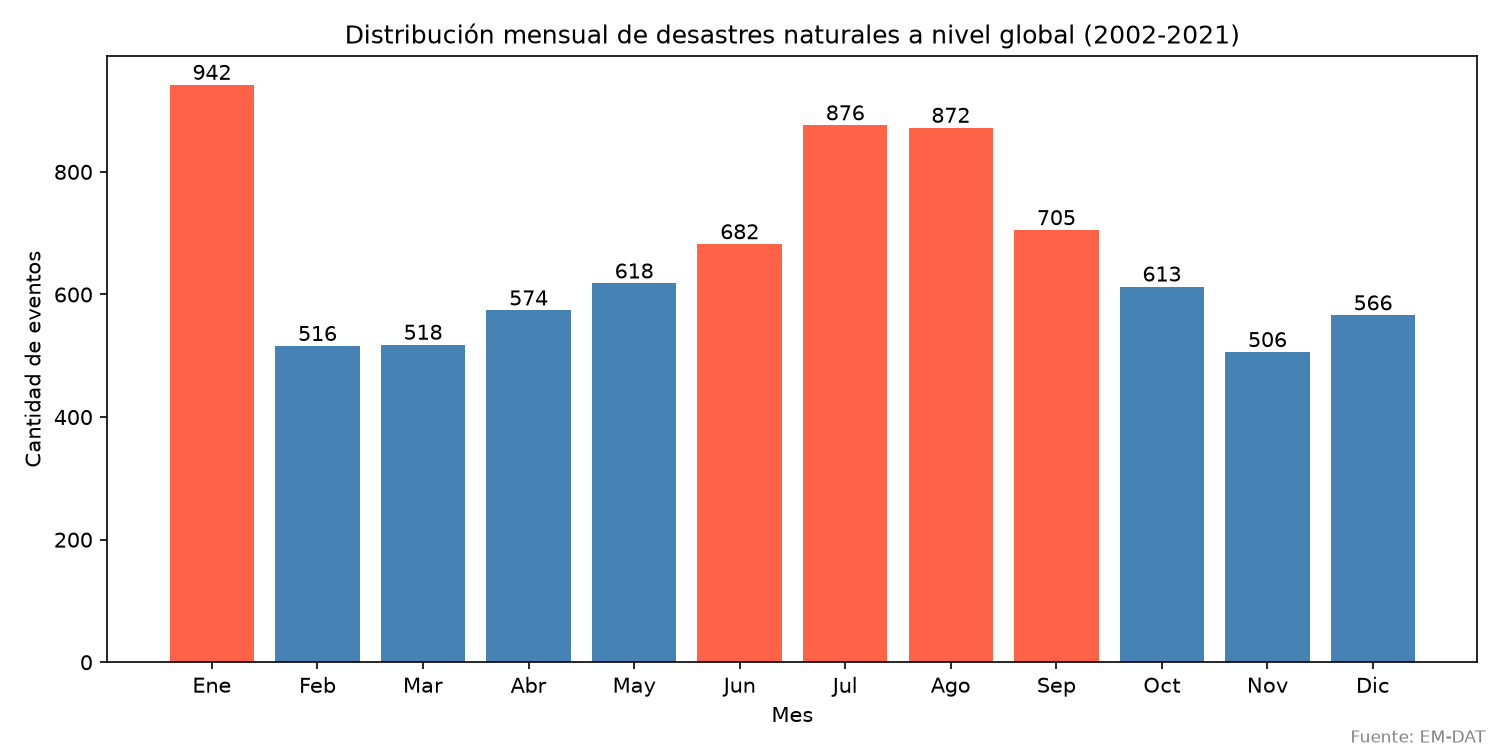

In [4]:
display(Image(f"{RAIZ}/{config['rutas']['graficos']}/estacionalidad_mensual.png"))

### Tendencia reciente (2002-2021)
Se observa que la cantidad de desastres naturales registrados muestra una tendencia 
decreciente en las últimas dos décadas, con una caída estimada de 57 
eventos por década. El año con más registros fue 2002 (505 eventos) y el 
de menor cantidad, 2021 (317 eventos).

Este resultado es contraintuitivo si se asume que el cambio climático 
debería traducirse en más desastres reportados con el paso del tiempo. 

Una explicacion puede ser tambien que hayan cambiado los criterios o la exhaustividad de los registros, es posible que en años de mayor cobertura mediaticas de desastres naturales se hayan documentado mas cantidad de eventos de menor escala que por ejemplo el tsunami de 2004, mientras que en años recientes el criterio de inclusión en 
la base sea más estricto. 

Esta es una limitación inherente a trabajar con 
datos de reporte histórico, y no necesariamente una  
disminución real de la ocurrencia de desastres naturales en el mundo.

Por tipo de evento, `Flood` (inundaciones) es la categoría dominante

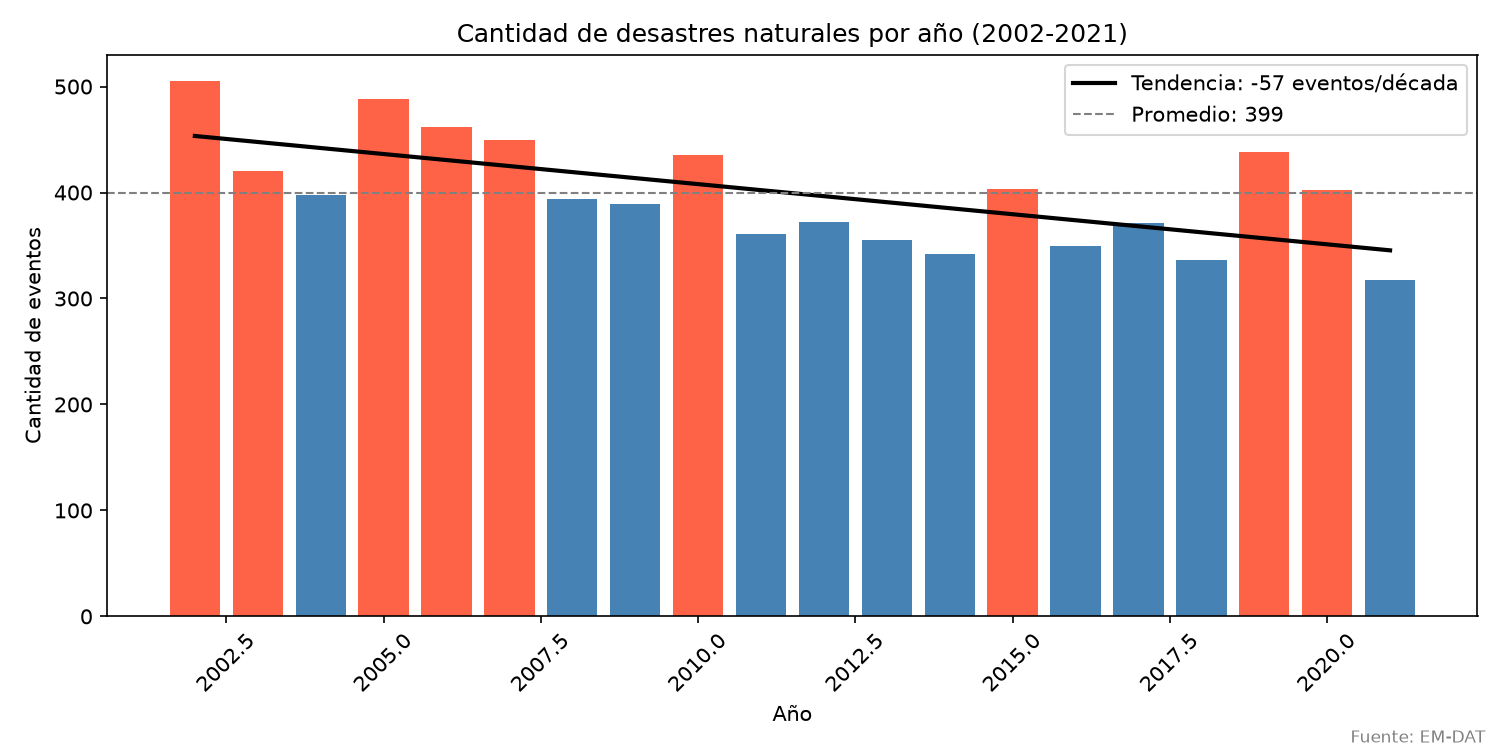

In [5]:
display(Image(f"{RAIZ}/{config['rutas']['graficos']}/tendencia_anual.png"))

### Promedio de muertes vs. cantidad de casos reportados

El gráfico permite contrastar dos dimensiones del impacto de cada tipo de 
desastre: qué tan frecuente es (eje Y) y qué tan letal resulta, en promedio, 
cada vez que ocurre (eje X). Esto revela un patrón claro: los tipos de 
desastre no se agrupan de forma uniforme, sino en dos perfiles bien 
diferenciados.

Por un lado, las inundaciones, tormentas y epidemias combinan alta frecuencia con 
baja o moderada letalidad promedio: son eventos que ocurren con regularidad pero no causan una gran cantidad de muertes por evento. 

Por otro lado, los terremotos y sequias ocurren con menor frecuencia, pero cuando suceden, su 
letalidad promedio es de las mas altas.

Esto es relevante porque la cantidad de eventos por sí sola (vimos en el analisis que el desastre dominante es FLood, inundaciones) no refleja el nivel real de riesgo humano: un tipo de desastre poco 
frecuente pero altamente letal, como el terremoto, puede representar un 
riesgo mayor en términos de vidas humanas que uno mucho más común pero 
menos mortal.

Se debe aclarar ademas que los promedios de desastres con pocos casos reportados deben tomarse con 
cautela, ya que un único evento extremo puede distorsionar fuertemente el resultado.

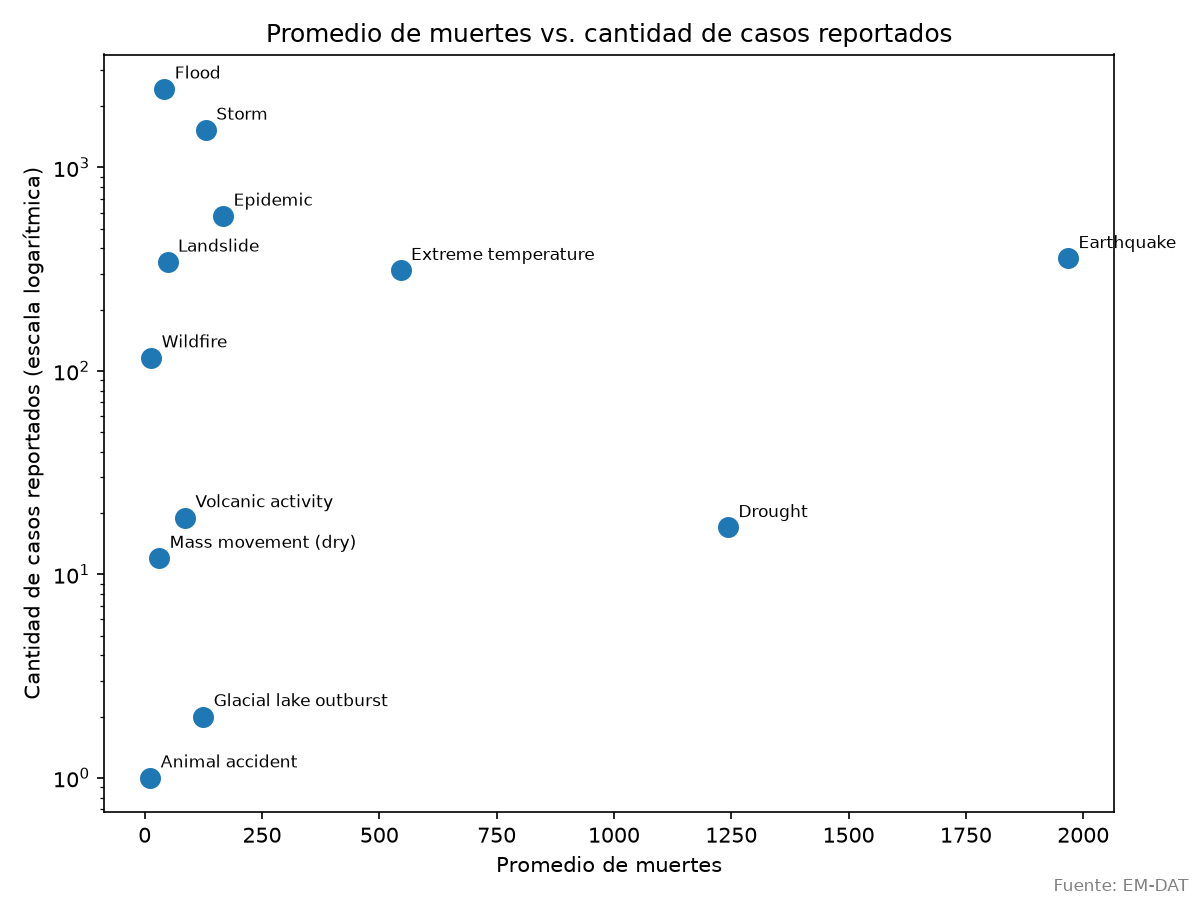

In [6]:
display(Image(f"{RAIZ}/{config['rutas']['graficos']}/letalidad_por_disaster.png"))

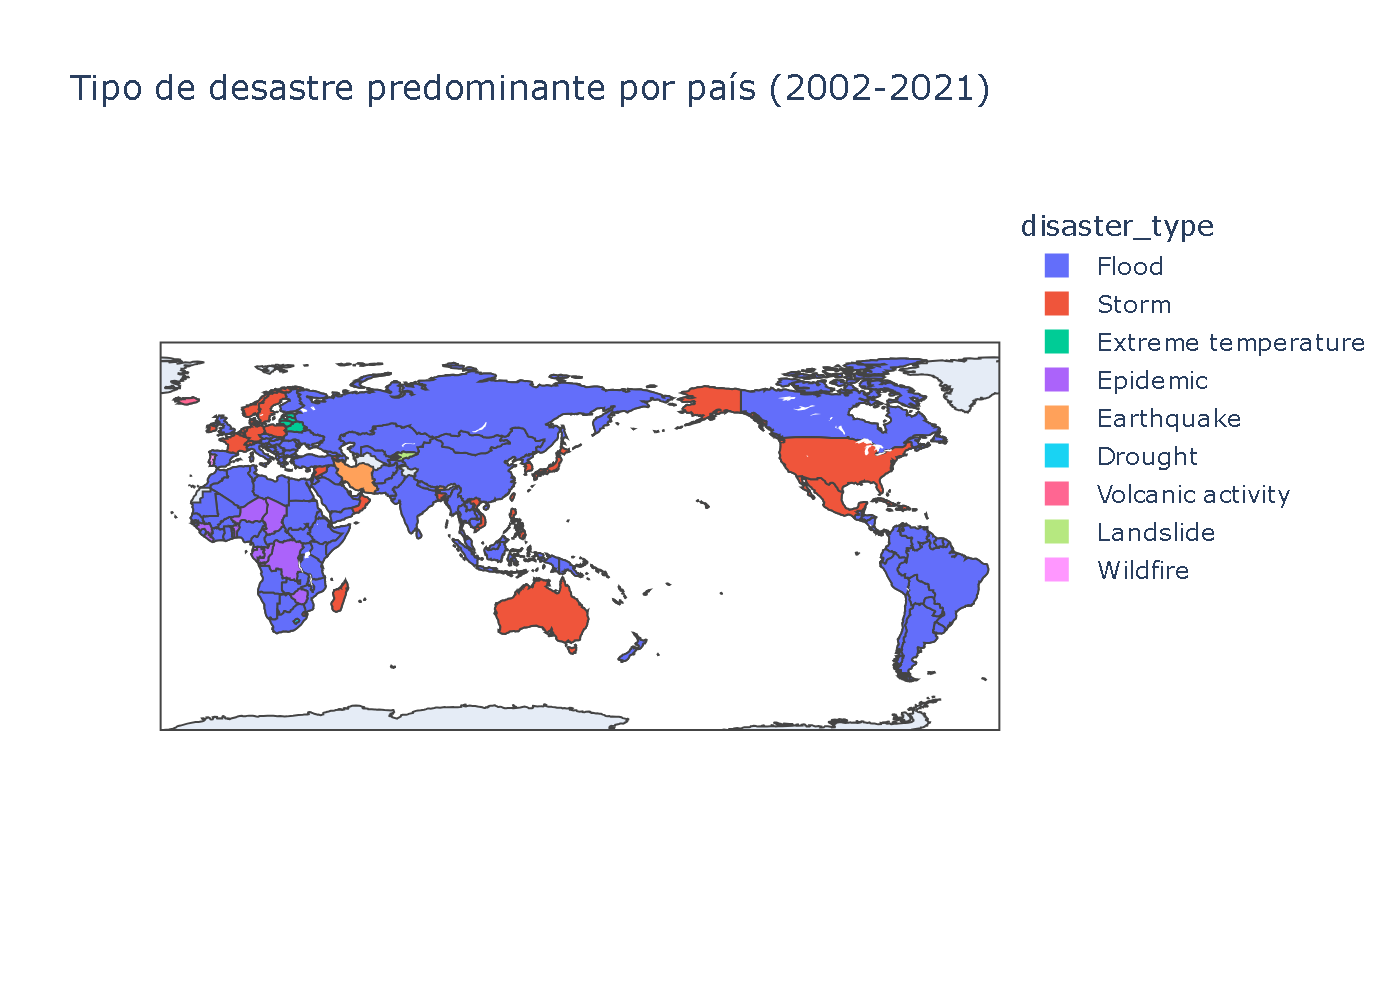

In [7]:
display(Image(f"{RAIZ}/{config['rutas']['graficos']}/tipo_predominante_por_pais.png"))

## Disaster Type × mes en Argentina (estacionalidad)

### Estacionalidad de desastres naturales en Argentina (2002-2021)

Al acotar el análisis a Argentina, inundacion es ampliamente el tipo de 
desastre más frecuente, con un pico marcado en abril y una 
concentración general en enero-abril, coincidiente con el verano 
y el otoño, época de tormentas severas e inundaciones en el litoral y el 
área metropolitana. Se observa un segundo repunte más leve entre octubre y 
diciembre.

El resto de los tipos de desastre (terremotos, sequías, deslizamientos, 
actividad volcánica) aparecen de forma muy esporádica, con 1 a 3 casos 
puntuales por mes. 

Esto es esperable dado el volumen reducido de datos al acotar a un solo país durante 20 años


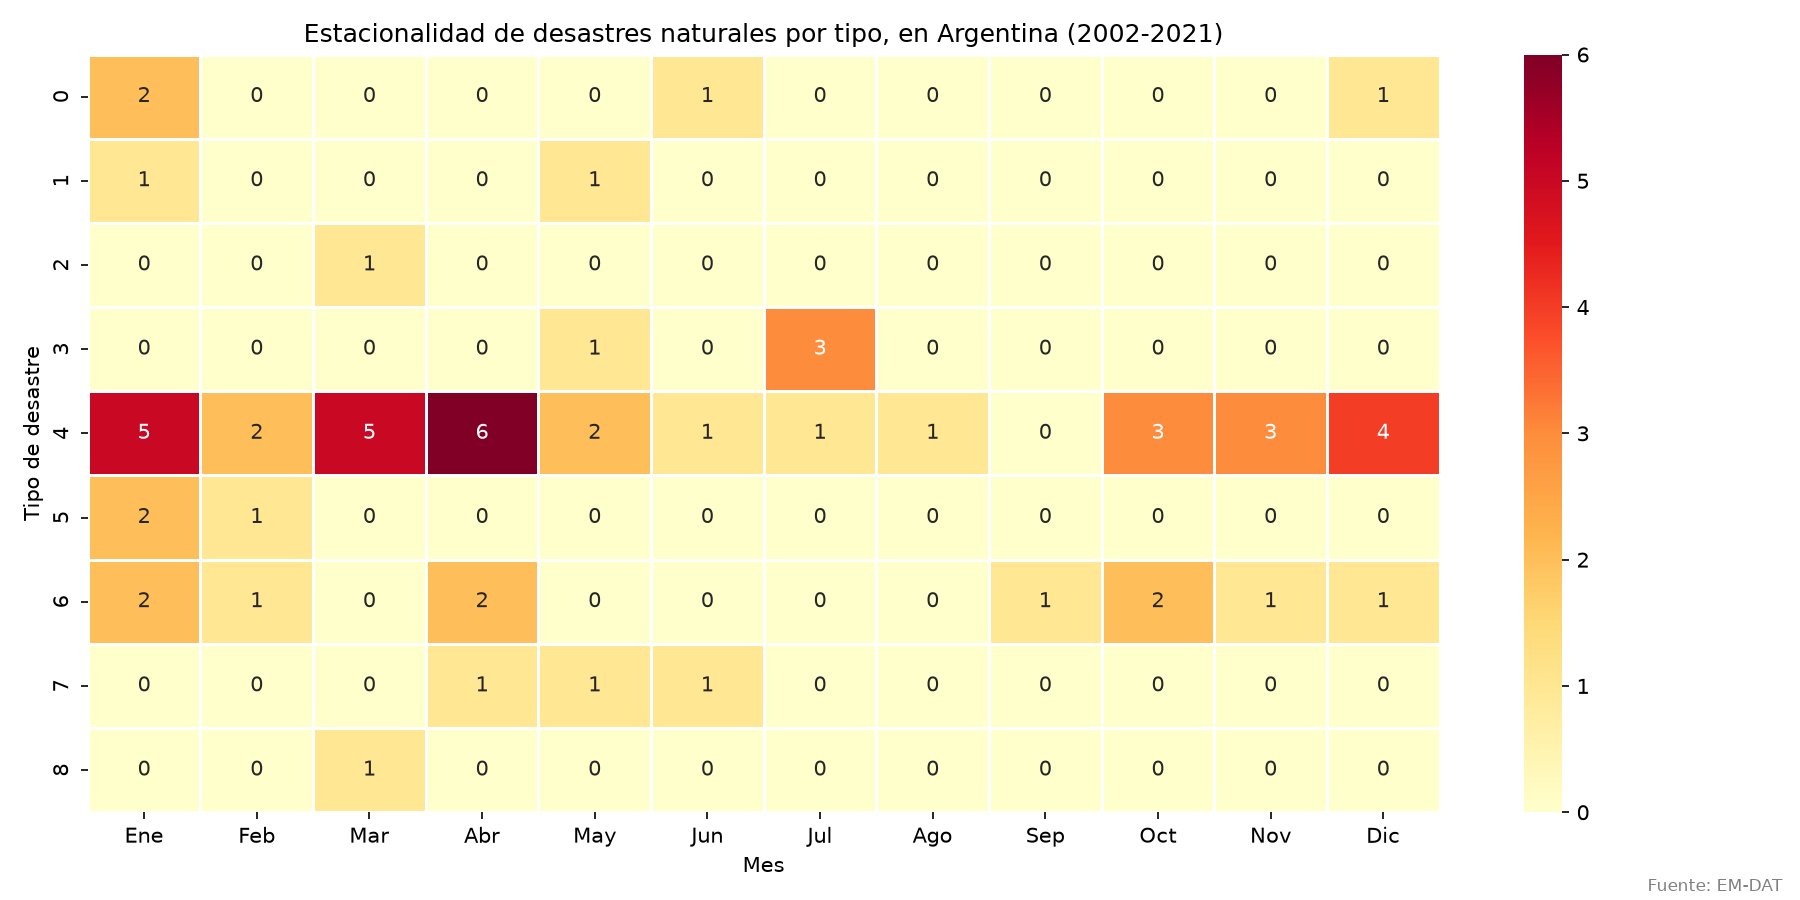

In [8]:
display(Image(f"{RAIZ}/{config['rutas']['graficos']}/estacionalidad_argentina.png"))